<a href="https://colab.research.google.com/github/Ishra18-hub/Solar-Desalination-ML/blob/main/09_eda_start.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SETUP

In [2]:
# Topic: Exploratory Data Analysis (EDA) on Desalination Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup complete")

Setup complete


DATA LOAD

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('desalination_data.csv')
print(" Data ")
print(df)

Saving desalination_data.csv to desalination_data.csv
 Data 
   Temperature_K  Air_Flow_ms  Solar_Irradiance_Wm2  Ambient_Temperature_K  \
0            320            5                   400                    285   
1            333            8                   600                    290   
2            345           10                   800                    295   
3            354           12                  1000                    300   
4            365           15                  1200                    305   

   Droplet_Size_um  Evaporation_Rate_relative  Freshwater_Yield_relative  \
0              500                       0.45                       0.40   
1              300                       0.65                       0.58   
2              200                       0.82                       0.75   
3              100                       1.00                       1.00   
4               50                       1.28                       1.20   

   Condensati

BASIC INFO

In [4]:
print(" Shape ")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

 Shape 
Rows: 5, Columns: 9

Column Names
['Temperature_K', 'Air_Flow_ms', 'Solar_Irradiance_Wm2', 'Ambient_Temperature_K', 'Droplet_Size_um', 'Evaporation_Rate_relative', 'Freshwater_Yield_relative', 'Condensation_Efficiency', 'Heat_Loss']

Data Types
Temperature_K                  int64
Air_Flow_ms                    int64
Solar_Irradiance_Wm2           int64
Ambient_Temperature_K          int64
Droplet_Size_um                int64
Evaporation_Rate_relative    float64
Freshwater_Yield_relative    float64
Condensation_Efficiency      float64
Heat_Loss                    float64
dtype: object

Missing Values
Temperature_K                0
Air_Flow_ms                  0
Solar_Irradiance_Wm2         0
Ambient_Temperature_K        0
Droplet_Size_um              0
Evaporation_Rate_relative    0
Freshwater_Yield_relative    0
Condensation_Efficiency      0
Heat_Loss                    0
dtype: int64


STATISTICS

In [5]:
print(" Summary Statistics ")
print(df.describe())

print("\n Mean values ")
print(df.mean())

 Summary Statistics 
       Temperature_K  Air_Flow_ms  Solar_Irradiance_Wm2  \
count       5.000000     5.000000              5.000000   
mean      343.400000    10.000000            800.000000   
std        17.586927     3.807887            316.227766   
min       320.000000     5.000000            400.000000   
25%       333.000000     8.000000            600.000000   
50%       345.000000    10.000000            800.000000   
75%       354.000000    12.000000           1000.000000   
max       365.000000    15.000000           1200.000000   

       Ambient_Temperature_K  Droplet_Size_um  Evaporation_Rate_relative  \
count               5.000000         5.000000                   5.000000   
mean              295.000000       230.000000                   0.840000   
std                 7.905694       178.885438                   0.319296   
min               285.000000        50.000000                   0.450000   
25%               290.000000       100.000000                   0.6

CORRELATION

In [6]:
print(" Correlation Matrix ")
print(df.corr())

# Which feature correlates most with Freshwater_Yield_relative?
print("\n Correlation with Target ")
print(df.corr()['Freshwater_Yield_relative'].sort_values(ascending=False))

 Correlation Matrix 
                           Temperature_K  Air_Flow_ms  Solar_Irradiance_Wm2  \
Temperature_K                   1.000000     0.996729              0.997937   
Air_Flow_ms                     0.996729     1.000000              0.996546   
Solar_Irradiance_Wm2            0.997937     0.996546              1.000000   
Ambient_Temperature_K           0.997937     0.996546              1.000000   
Droplet_Size_um                -0.982186    -0.972583             -0.972272   
Evaporation_Rate_relative       0.991463     0.997250              0.995342   
Freshwater_Yield_relative       0.991472     0.992617              0.997704   
Condensation_Efficiency        -0.976691    -0.987364             -0.979130   
Heat_Loss                       0.991397     0.996212              0.995893   

                           Ambient_Temperature_K  Droplet_Size_um  \
Temperature_K                           0.997937        -0.982186   
Air_Flow_ms                             0.996546  

 Visualization — Temperature vs Yield

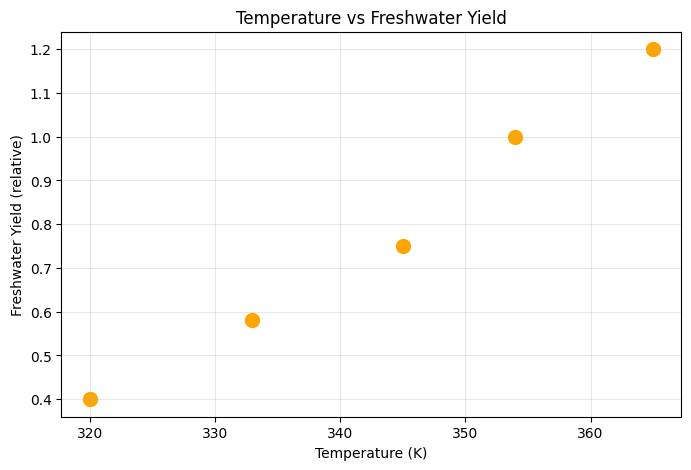

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Temperature_K'], df['Freshwater_Yield_relative'],
            color='orange', s=100)
plt.xlabel('Temperature (K)')
plt.ylabel('Freshwater Yield (relative)')
plt.title('Temperature vs Freshwater Yield')
plt.grid(True, alpha=0.3)
plt.show()

Visualization — All features vs Target

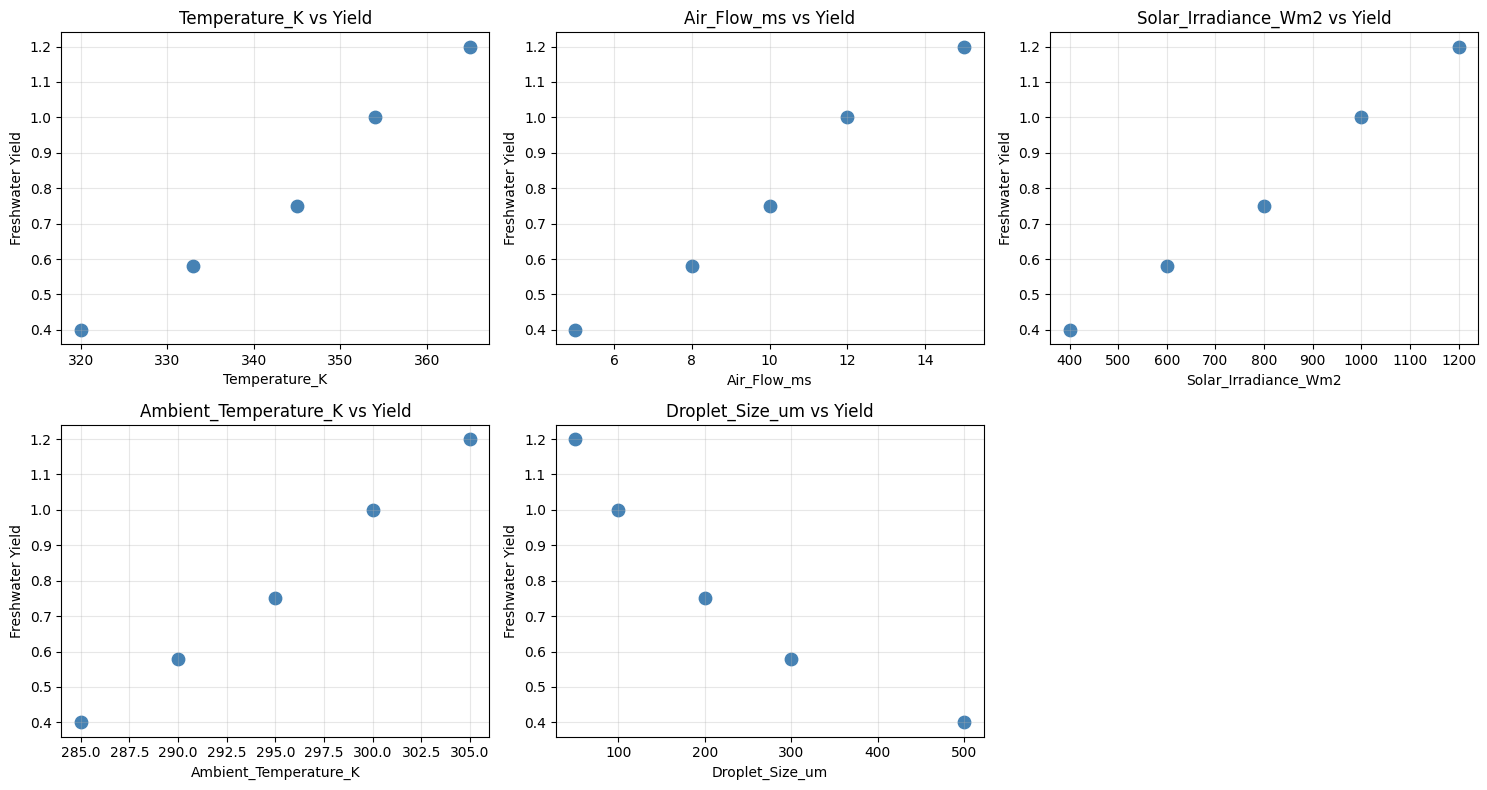

In [8]:
features = ['Temperature_K', 'Air_Flow_ms', 'Solar_Irradiance_Wm2',
            'Ambient_Temperature_K', 'Droplet_Size_um']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Freshwater_Yield_relative'],
                    color='steelblue', s=80)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Freshwater Yield')
    axes[i].set_title(f'{feature} vs Yield')
    axes[i].grid(True, alpha=0.3)

# Hide last empty plot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

Correlation heatmap

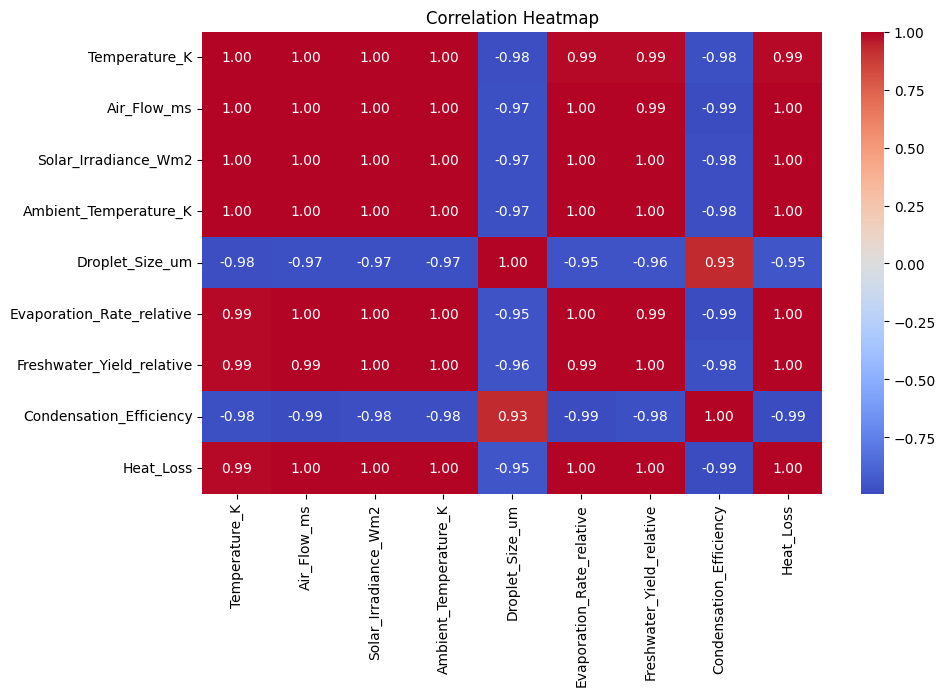

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()